# Catalog coverage — how Western, Non-Western, and International catalogs reference individuals across polities.

In [1]:
import random
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objects as go
from IPython.display import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../../data/humans_clean.duckdb'

COLORS = {
    'western_catalog':       '#2171b5',
    'non_western_catalog':   '#b5542a',
    'international_catalog': '#6a9e3a',
    'western_wikipedia':     '#9ecae1',
    'non_western_wikipedia': '#dfa3c4',
    'both_catalogs':         '#7f7f7f',
    'both_wikipedias':       '#bdb6d6',
    'no_catalog_no_wiki':    '#d9d9d9',
    'neutral_bar':           '#4a4a4a',
}
LIGHT_COLORS = {
    COLORS['western_wikipedia'],
    COLORS['non_western_wikipedia'],
    COLORS['both_wikipedias'],
    COLORS['no_catalog_no_wiki'],
}

CHINESE_POLITY_COLORS = {
    'Shang':          '#6c2a2c',
    'Zhou':           '#8e4f33',
    'Qin':            '#b07a3f',
    'Han':            '#c8a472',
    'Six Dynasties':  '#8e7a8a',
    'Sui':            '#6c8a8a',
    'Tang':           '#4f8a98',
    'Five Dynasties': '#5b6f8e',
    'Song':           '#3e5b8e',
    'Yuan':           '#6a4f8a',
    'Ming':           '#8e4f7a',
    'Qing':           '#a05a6a',
}

plt.rcParams.update({
    'figure.dpi':       120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   11,
})


## Classification rules

In [2]:
WESTERN_COUNTRIES = [
    'United States',
    'Washington, D.C.',
    'Germany',
    'France',
    'Poland',
    'Netherlands',
    'Kingdom of the Netherlands',
    'United Kingdom',
    'Wales',
    'Italy',
    'Kingdom of Italy',
    'Spain',
    'Sweden',
    'Norway',
    'Finland',
    'Denmark',
    'Faroe Islands',
    'Austria',
    'Belgium',
    'Switzerland',
    'Portugal',
    'Czech Republic',
    'Slovakia',
    'Greece',
    'Hungary',
    'Ireland',
    'Canada',
    'Australia',
    'New Zealand',
    'Romania',
    'Croatia',
    'Serbia',
    'Slovenia',
    'Lithuania',
    'Latvia',
    'Estonia',
    'Bulgaria',
    'Iceland',
    'Luxembourg',
    'Liechtenstein',
    'Andorra',
    'Cyprus',
    'Vatican City',
    'Weimar Republic',
    'German Reich',
]

WESTERN_WIKIPEDIA_LANGUAGES = [
    'en', 'simple', 'de', 'de-at', 'de-ch', 'als', 'bar', 'pdc', 'ksh',
    'fr', 'frp', 'oc', 'co', 'br', 'wa',
    'es', 'ast', 'an', 'ext', 'mwl', 'lad',
    'it', 'fur', 'lij', 'lmo', 'nap', 'pms', 'rm', 'sc', 'scn', 'vec',
    'pt',
    'nl', 'fy', 'li', 'zea', 'nds-nl', 'af', 'vls', 'frr', 'stq',
    'pl', 'csb', 'szl',
    'sv', 'no', 'nn', 'nb', 'fi', 'da', 'fo', 'is',
    'cs', 'sk', 'sr', 'hr', 'sl', 'bs', 'sh', 'dsb', 'hsb',
    'el', 'grc',
    'hu',
    'ga', 'cy', 'gd', 'gv', 'kw',
    'ro', 'mo', 'roa-rup',
    'lt', 'lv', 'et',
    'bg', 'mk',
    'lb', 'gsw', 'pfl',
    'ca', 'gl', 'eu',
    'la',
    'mt',
    'nds', 'eo', 'ia', 'ie', 'vo',
]

NON_WESTERN_WIKIPEDIA_LANGUAGES = [
    'ar', 'arz', 'ru', 'uk', 'be', 'be-tarask', 'kk', 'ky', 'uz', 'tg', 'tk', 'mn',
    'ja', 'zh', 'zh-yue', 'yue', 'wuu', 'hak', 'lzh', 'ko',
    'id', 'ms', 'jv', 'su', 'min', 'ace', 'vi', 'th', 'lo', 'km', 'my',
    'tr', 'az', 'azb', 'ckb', 'fa', 'he',
    'ur', 'pnb', 'ps', 'sd', 'hi', 'bn', 'as', 'or', 'ta', 'te', 'ml',
    'kn', 'mr', 'gu', 'pa', 'ne', 'si', 'dv',
    'ka', 'hy', 'yi',
    'tl', 'ceb', 'war',
    'ig', 'yo', 'ha', 'sw', 'zu', 'xh', 'st', 'sn', 'ny', 'rw', 'lg',
    'tn', 'ts', 've', 'nso', 'ss', 'om', 'so', 'ti', 'am', 'tw', 'ee',
    'fon', 'kg', 'lua', 'sg', 'ln', 'mg', 'kab',
    'sat', 'bho', 'mai', 'new', 'anp', 'doi', 'ks', 'sa', 'pi', 'dty',
    'awa', 'shn', 'tcy', 'kok',
]

print(f'WESTERN_COUNTRIES:               {len(WESTERN_COUNTRIES)}')
print(f'WESTERN_WIKIPEDIA_LANGUAGES:     {len(WESTERN_WIKIPEDIA_LANGUAGES)}')
print(f'NON_WESTERN_WIKIPEDIA_LANGUAGES: {len(NON_WESTERN_WIKIPEDIA_LANGUAGES)}')


WESTERN_COUNTRIES:               45
WESTERN_WIKIPEDIA_LANGUAGES:     90
NON_WESTERN_WIKIPEDIA_LANGUAGES: 104


## Connect

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)


## Catalog categories  (each property classified Western / Non-Western / International)

In [4]:
identifier_types = con.execute(
    'SELECT property_id, country_name FROM identifier_types'
).pl()

print('shape:', identifier_types.shape)
identifier_types.head()


shape: (5169, 2)


property_id,country_name
str,str
"""P3442""",null
"""P3370""","""France"""
"""P3083""","""France"""
"""P3375""","""Germany"""
"""P3500""","""United States"""


In [5]:
catalog_categories = identifier_types.with_columns(
    pl.when(pl.col('country_name').is_in(WESTERN_COUNTRIES)).then(pl.lit('western'))
    .when(pl.col('country_name') == 'internationality').then(pl.lit('international'))
    .when(pl.col('country_name').is_not_null()).then(pl.lit('non_western'))
    .otherwise(None)
    .alias('category')
)

print('shape:', catalog_categories.shape)
catalog_categories.head()


shape: (5169, 3)


property_id,country_name,category
str,str,str
"""P3442""",null,null
"""P3370""","""France""","""western"""
"""P3083""","""France""","""western"""
"""P3375""","""Germany""","""western"""
"""P3500""","""United States""","""western"""


## Wikipedia categories  (each site classified Western / Non-Western)

In [6]:
wikipedia_sites = con.execute(
    "SELECT DISTINCT site FROM wikimedia_links WHERE site LIKE '%.wikipedia.org'"
).pl()

print('shape:', wikipedia_sites.shape)
wikipedia_sites.head()


shape: (349, 1)


site
str
"""bg.wikipedia.org"""
"""nl.wikipedia.org"""
"""pt.wikipedia.org"""
"""be.wikipedia.org"""
"""hyw.wikipedia.org"""


In [7]:
wikipedia_categories = (
    wikipedia_sites
    .with_columns(pl.col('site').str.split('.').list.get(0).alias('language'))
    .with_columns(
        pl.when(pl.col('language').is_in(WESTERN_WIKIPEDIA_LANGUAGES)).then(pl.lit('western'))
        .when(pl.col('language').is_in(NON_WESTERN_WIKIPEDIA_LANGUAGES)).then(pl.lit('non_western'))
        .otherwise(None)
        .alias('category')
    )
)

print('shape:', wikipedia_categories.shape)
wikipedia_categories.head()


shape: (349, 3)


site,language,category
str,str,str
"""bg.wikipedia.org""","""bg""","""western"""
"""nl.wikipedia.org""","""nl""","""western"""
"""pt.wikipedia.org""","""pt""","""western"""
"""be.wikipedia.org""","""be""","""non_western"""
"""hyw.wikipedia.org""","""hyw""",null


## Identifier links  (one row per individual × catalog property)

In [8]:
identifier_links = con.execute(
    'SELECT wikidata_id, property_id FROM identifiers'
).pl()

print('shape:', identifier_links.shape)
identifier_links.head()


shape: (59508342, 2)


wikidata_id,property_id
str,str
"""Q98837919""","""P10001"""
"""Q98837919""","""P12302"""
"""Q98837919""","""P2020"""
"""Q98837919""","""P2446"""
"""Q98837919""","""P3537"""


## Catalog flags per individual  (any Western / Non-Western / International catalog?)

In [9]:
classified_catalogs = catalog_categories.filter(pl.col('category').is_not_null()).select('property_id', 'category')

catalog_flags = (
    identifier_links
    .join(classified_catalogs, on='property_id', how='inner')
    .group_by('wikidata_id')
    .agg(
        (pl.col('category') == 'western').any().alias('has_western_catalog'),
        (pl.col('category') == 'non_western').any().alias('has_non_western_catalog'),
        (pl.col('category') == 'international').any().alias('has_international_catalog'),
    )
)

print('shape:', catalog_flags.shape)
catalog_flags.head()


shape: (5797690, 4)


wikidata_id,has_western_catalog,has_non_western_catalog,has_international_catalog
str,bool,bool,bool
"""Q102275108""",true,true,false
"""Q131866635""",true,false,false
"""Q133352065""",true,false,false
"""Q3493957""",true,false,false
"""Q137349240""",true,false,false


## Wikipedia links  (one row per individual × Wikipedia site)

In [10]:
wikipedia_links = con.execute(
    "SELECT wikidata_id, site FROM wikimedia_links WHERE site LIKE '%.wikipedia.org'"
).pl()

print('shape:', wikipedia_links.shape)
wikipedia_links.head()


shape: (14043730, 2)


wikidata_id,site
str,str
"""Q112484246""","""ro.wikipedia.org"""
"""Q1543246""","""ar.wikipedia.org"""
"""Q1543246""","""de.wikipedia.org"""
"""Q91258802""","""en.wikipedia.org"""
"""Q91258802""","""pnb.wikipedia.org"""


## Wikipedia flags per individual  (any Western / Non-Western Wikipedia?)

In [11]:
classified_wikipedias = wikipedia_categories.filter(pl.col('category').is_not_null()).select('site', 'category')

wikipedia_flags = (
    wikipedia_links
    .join(classified_wikipedias, on='site', how='inner')
    .group_by('wikidata_id')
    .agg(
        (pl.col('category') == 'western').any().alias('has_western_wikipedia'),
        (pl.col('category') == 'non_western').any().alias('has_non_western_wikipedia'),
    )
)

print('shape:', wikipedia_flags.shape)
wikipedia_flags.head()


shape: (4720084, 3)


wikidata_id,has_western_wikipedia,has_non_western_wikipedia
str,bool,bool
"""Q432505""",true,true
"""Q7437053""",true,true
"""Q19385151""",true,false
"""Q18639397""",true,true
"""Q115277""",true,true


## Polity matches  (one row per individual × polity)

In [12]:
polity_matches = con.execute("""
    SELECT wikidata_id, polity_name, floruit_period_start
    FROM   individuals_cliopatria
    WHERE  polity_name IS NOT NULL
""").pl()

print('shape:', polity_matches.shape)
polity_matches.head()


shape: (5065026, 3)


wikidata_id,polity_name,floruit_period_start
str,str,i32
"""Q107522""","""Weimar Republic""",1908
"""Q107522041""","""Union of Soviet Socialist Repu…",1976
"""Q107522056""","""Venezuela""",1977
"""Q107522108""","""United States of America""",1962
"""Q107522122""","""Russian Federation""",1989


## Birth years per individual

In [13]:
birth_years = con.execute(
    'SELECT wikidata_id, birth_year FROM individuals_floruit_period'
).pl()

print('shape:', birth_years.shape)
birth_years.head()


shape: (13003420, 2)


wikidata_id,birth_year
str,i64
"""Q101553124""",null
"""Q101553254""",null
"""Q101553398""",1975
"""Q101553548""",1947
"""Q101553561""",null


## Per (individual × polity) joined to flags + birth/floruit dates

In [14]:
flag_columns = [
    'has_western_catalog',
    'has_non_western_catalog',
    'has_international_catalog',
    'has_western_wikipedia',
    'has_non_western_wikipedia',
]

individual_polity_flags = (
    polity_matches
    .join(birth_years,     on='wikidata_id', how='left')
    .join(catalog_flags,   on='wikidata_id', how='left')
    .join(wikipedia_flags, on='wikidata_id', how='left')
    .with_columns([pl.col(column).fill_null(False) for column in flag_columns])
)

assert individual_polity_flags.height == polity_matches.height

print('shape:', individual_polity_flags.shape)
individual_polity_flags.head()


shape: (5065026, 9)


wikidata_id,polity_name,floruit_period_start,birth_year,has_western_catalog,has_non_western_catalog,has_international_catalog,has_western_wikipedia,has_non_western_wikipedia
str,str,i32,i64,bool,bool,bool,bool,bool
"""Q107522""","""Weimar Republic""",1908,1878,true,false,false,true,true
"""Q107522041""","""Union of Soviet Socialist Repu…",1976,1946,false,true,false,false,true
"""Q107522056""","""Venezuela""",1977,1947,true,false,false,true,false
"""Q107522108""","""United States of America""",1962,1932,false,false,false,false,false
"""Q107522122""","""Russian Federation""",1989,1959,false,false,false,false,false


## Coverage label  (8 mutually-exclusive buckets)

In [15]:
COVERAGE_COLUMNS = [
    'western_catalog_only',
    'non_western_catalog_only',
    'both_catalogs',
    'international_only',
    'western_wikipedia_only',
    'non_western_wikipedia_only',
    'both_wikipedias',
    'no_catalog_no_wikipedia',
]

individual_coverage = individual_polity_flags.with_columns(
    pl.when(pl.col('has_western_catalog')     & ~pl.col('has_non_western_catalog')).then(pl.lit('western_catalog_only'))
    .when(pl.col('has_non_western_catalog') & ~pl.col('has_western_catalog')).then(pl.lit('non_western_catalog_only'))
    .when(pl.col('has_western_catalog')     & pl.col('has_non_western_catalog')).then(pl.lit('both_catalogs'))
    .when(pl.col('has_international_catalog')).then(pl.lit('international_only'))
    .when(pl.col('has_western_wikipedia')     & ~pl.col('has_non_western_wikipedia')).then(pl.lit('western_wikipedia_only'))
    .when(pl.col('has_non_western_wikipedia') & ~pl.col('has_western_wikipedia')).then(pl.lit('non_western_wikipedia_only'))
    .when(pl.col('has_western_wikipedia')     & pl.col('has_non_western_wikipedia')).then(pl.lit('both_wikipedias'))
    .otherwise(pl.lit('no_catalog_no_wikipedia'))
    .alias('coverage')
)

print('shape:', individual_coverage.shape)
individual_coverage.head()


shape: (5065026, 10)


wikidata_id,polity_name,floruit_period_start,birth_year,has_western_catalog,has_non_western_catalog,has_international_catalog,has_western_wikipedia,has_non_western_wikipedia,coverage
str,str,i32,i64,bool,bool,bool,bool,bool,str
"""Q107522""","""Weimar Republic""",1908,1878,true,false,false,true,true,"""western_catalog_only"""
"""Q107522041""","""Union of Soviet Socialist Repu…",1976,1946,false,true,false,false,true,"""non_western_catalog_only"""
"""Q107522056""","""Venezuela""",1977,1947,true,false,false,true,false,"""western_catalog_only"""
"""Q107522108""","""United States of America""",1962,1932,false,false,false,false,false,"""no_catalog_no_wikipedia"""
"""Q107522122""","""Russian Federation""",1989,1959,false,false,false,false,false,"""no_catalog_no_wikipedia"""


## Catalog names for the polities used in Fig 3 (Tang/Roman) and Fig 5 (Chinese Sankey)

In [16]:
TANG_ROMAN_POLITIES = [
    'Tang Dynasty',
    'Roman Empire',
]
CHINESE_POLITIES = [
    'Shang Dynasty',
    'Zhou Dynasty',
    'Qin Dynasty',
    'Han Dynasty',
    'Xin Dynasty',
    'Western Jin',
    'Liu Song Dynasty',
    'Liang Dynasty',
    'Chen Dynasty',
    'Northern Wei',
    'Eastern Wei',
    'Western Wei',
    'Northern Zhou',
    'Northern Qi',
    'Sui Dynasty',
    'Tang Dynasty',
    'Five Dynasties and Ten Kingdoms',
    'Liao Dynasty',
    'Western Xia',
    'Northern Song',
    'Southern Song',
    'Yuan Dynasty',
    'Ming Dynasty',
    'Qing Dynasty',
]
target_polities = sorted(set(TANG_ROMAN_POLITIES) | set(CHINESE_POLITIES))
placeholders = ','.join(['?'] * len(target_polities))

catalog_names = con.execute(f"""
    SELECT DISTINCT
        identifiers.wikidata_id,
        individuals_cliopatria.polity_name,
        identifiers.identifier_name,
        identifier_types.country_name AS catalog_country
    FROM        individuals_cliopatria
    JOIN        identifiers       USING (wikidata_id)
    LEFT JOIN   identifier_types  USING (property_id)
    WHERE       individuals_cliopatria.polity_name IN ({placeholders})
      AND       identifiers.identifier_name IS NOT NULL
""", target_polities).pl()

con.close()

print('shape:', catalog_names.shape)
catalog_names.head()


shape: (338265, 4)


wikidata_id,polity_name,identifier_name,catalog_country
str,str,str,str
"""Q44248""","""Roman Empire""","""Lur Encyclopedic Dictionary ID""","""Spain"""
"""Q44248""","""Roman Empire""","""NLP ID""","""Poland"""
"""Q44248""","""Roman Empire""","""ALCUIN philosopher ID""",null
"""Q82778""","""Roman Empire""","""Radio France person ID""","""France"""
"""Q82778""","""Roman Empire""","""Swedish Open Cultural Heritage…","""Sweden"""


## Fig 1 — Top 10 polities by Non-Western-only catalog share

In [17]:
MIN_INDIVIDUALS_PER_POLITY = 2000

def first_non_paren_segment(name):
    for part in name.split(';'):
        part = part.strip()
        if part and not part.startswith('('):
            return part
    return name.split(';')[0].strip('() ')

polity_coverage = (
    individual_coverage
    .with_columns(
        pl.col('polity_name')
          .map_elements(first_non_paren_segment, return_dtype=pl.Utf8)
          .alias('polity')
    )
    .group_by('polity', 'coverage').len()
    .pivot(values='len', index='polity', on='coverage', aggregate_function='sum')
    .fill_null(0)
)
for column in COVERAGE_COLUMNS:
    if column not in polity_coverage.columns:
        polity_coverage = polity_coverage.with_columns(pl.lit(0).alias(column))

polity_coverage = (
    polity_coverage
    .with_columns(pl.sum_horizontal(COVERAGE_COLUMNS).alias('total_individuals'))
    .filter(pl.col('total_individuals') >= MIN_INDIVIDUALS_PER_POLITY)
    .with_columns(
        (pl.col('non_western_catalog_only') / pl.col('total_individuals')).alias('non_western_share')
    )
)

top10_polities_by_non_western = polity_coverage.sort('non_western_share', descending=True).head(10)

print('shape:', top10_polities_by_non_western.shape)
top10_polities_by_non_western.select(['polity', 'total_individuals', 'non_western_catalog_only', 'non_western_share'])


shape: (10, 11)


polity,total_individuals,non_western_catalog_only,non_western_share
str,u32,u32,f64
"""Oriental Republic of Uruguay""",15939,8074,0.506556
"""Tanzania""",2027,532,0.262457
"""Republic of Indonesia""",75739,19564,0.258308
"""Russian Federation""",64267,12732,0.198111
"""Empire of Japan""",30328,5427,0.178944
"""Iraqi Republic""",3023,479,0.158452
"""Japan""",157355,24691,0.156913
"""Republic of Brazil""",53853,7963,0.147865
"""Federated Republic of Brazil""",9913,1453,0.146575


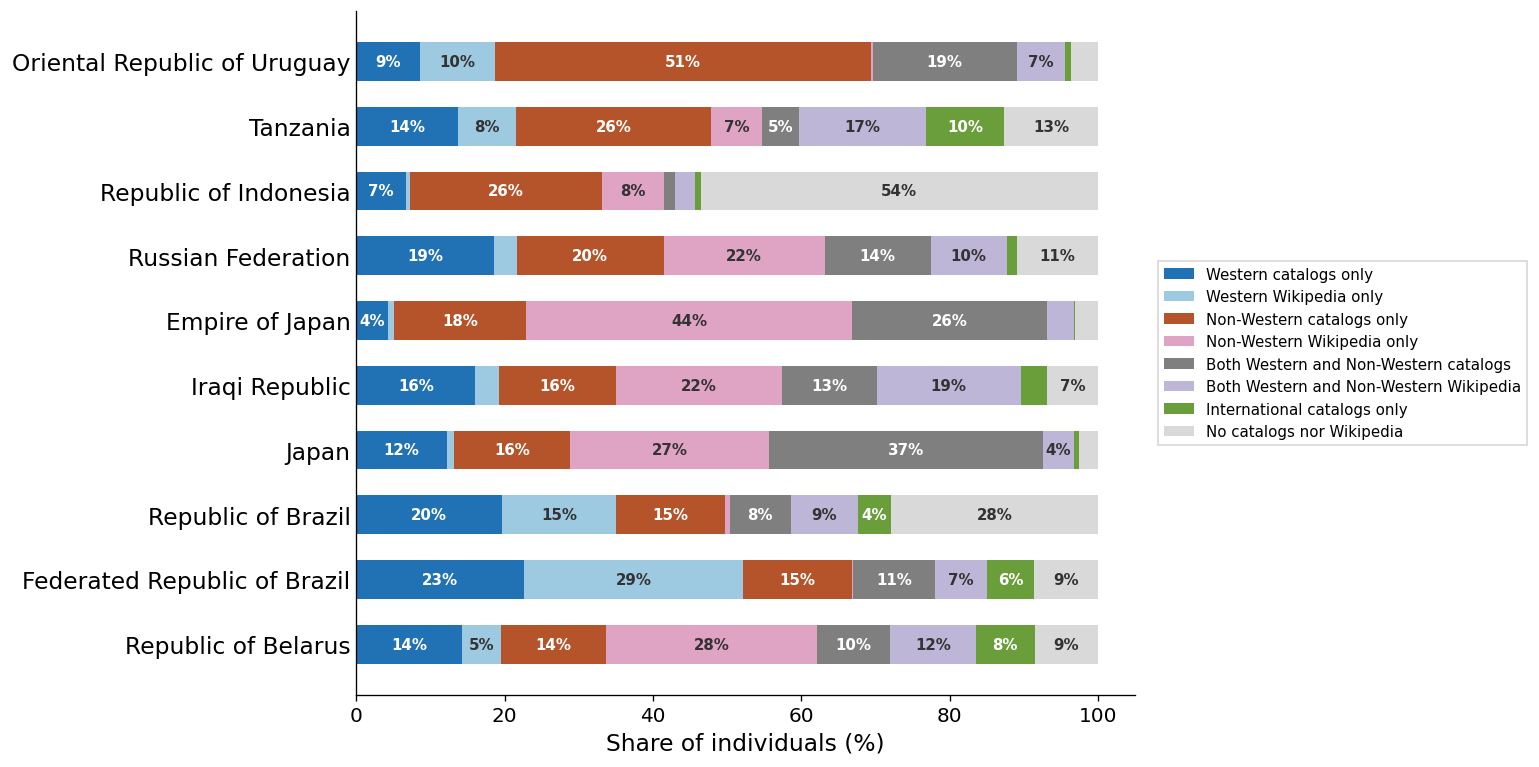

In [18]:
COVERAGE_SEGMENTS = [
    ('Western catalogs only',                  'western_catalog_only',       COLORS['western_catalog']),
    ('Western Wikipedia only',                 'western_wikipedia_only',     COLORS['western_wikipedia']),
    ('Non-Western catalogs only',              'non_western_catalog_only',   COLORS['non_western_catalog']),
    ('Non-Western Wikipedia only',             'non_western_wikipedia_only', COLORS['non_western_wikipedia']),
    ('Both Western and Non-Western catalogs',  'both_catalogs',              COLORS['both_catalogs']),
    ('Both Western and Non-Western Wikipedia', 'both_wikipedias',            COLORS['both_wikipedias']),
    ('International catalogs only',            'international_only',         COLORS['international_catalog']),
    ('No catalogs nor Wikipedia',              'no_catalog_no_wikipedia',    COLORS['no_catalog_no_wiki']),
]
LABEL_THRESHOLD_PERCENT = 4.0

bottom_up = top10_polities_by_non_western.reverse()
labels = bottom_up['polity'].to_list()
totals = bottom_up['total_individuals'].to_numpy()

fig, ax = plt.subplots(figsize=(13, 6.5))
y_positions = np.arange(len(labels))
left_edges = np.zeros(len(labels))

for segment_label, column, color in COVERAGE_SEGMENTS:
    percent_values = bottom_up[column].to_numpy() / totals * 100
    ax.barh(y_positions, percent_values, height=0.6, left=left_edges, color=color, label=segment_label)
    for i, (value, left_edge) in enumerate(zip(percent_values, left_edges)):
        if value >= LABEL_THRESHOLD_PERCENT:
            ax.text(
                left_edge + value / 2, y_positions[i], f'{value:.0f}%',
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='#333' if color in LIGHT_COLORS else 'white',
            )
    left_edges += percent_values

ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=14)
ax.set_xlabel('Share of individuals (%)', fontsize=14)
ax.set_xlim(0, 105)
ax.tick_params(axis='y', length=0)
ax.legend(
    fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5),
    frameon=True, fancybox=False, edgecolor='#cccccc',
)
plt.tight_layout()
plt.show()


## Fig 2 — Coverage distribution before vs after 1900

In [19]:
SPLIT_YEAR = 1900

period_coverage = (
    individual_coverage
    .unique(subset=['wikidata_id'], keep='first')
    .filter(pl.col('floruit_period_start').is_not_null())
    .with_columns(
        pl.when(pl.col('floruit_period_start') < SPLIT_YEAR)
          .then(pl.lit('Before 1900'))
          .otherwise(pl.lit('After 1900'))
          .alias('period')
    )
    .group_by('period', 'coverage').len()
    .pivot(values='len', index='period', on='coverage', aggregate_function='sum')
    .fill_null(0)
)
for column in COVERAGE_COLUMNS:
    if column not in period_coverage.columns:
        period_coverage = period_coverage.with_columns(pl.lit(0).alias(column))

period_coverage = period_coverage.with_columns(
    pl.sum_horizontal(COVERAGE_COLUMNS).alias('total_individuals')
)

print('shape:', period_coverage.shape)
period_coverage


shape: (2, 10)


period,western_catalog_only,international_only,both_catalogs,non_western_wikipedia_only,no_catalog_no_wikipedia,non_western_catalog_only,western_wikipedia_only,both_wikipedias,total_individuals
str,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""After 1900""",1586771,83584,468902,275784,612422,158814,546538,345106,4077921
"""Before 1900""",502403,11,48971,55171,192360,9652,132105,46432,987105


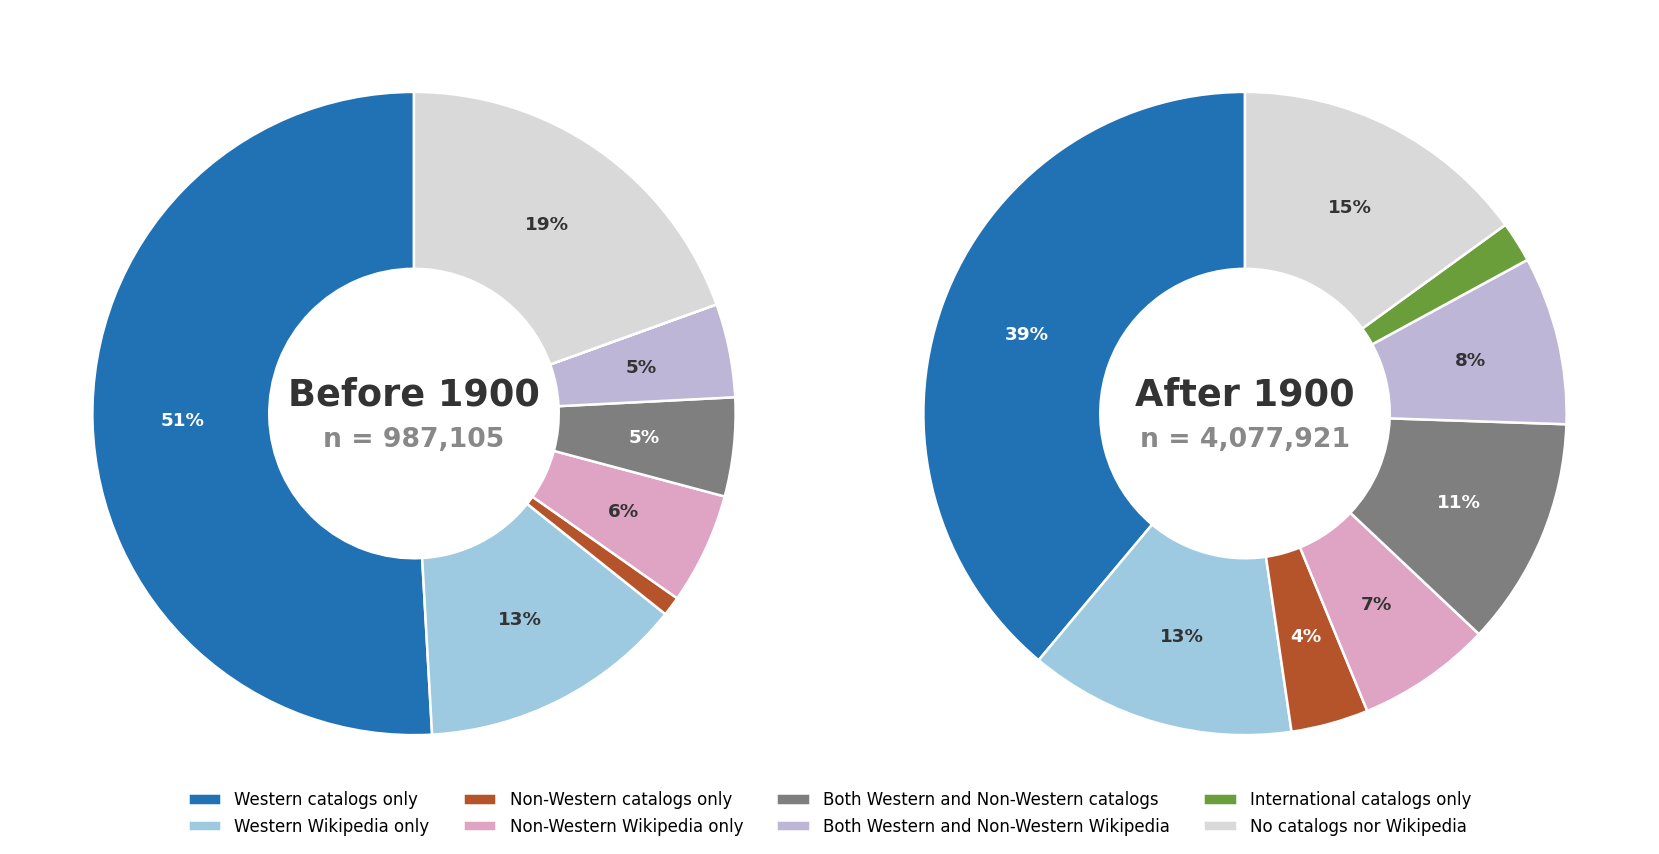

In [20]:
def percent_or_blank(percent):
    return f'{percent:.0f}%' if percent >= 3 else ''

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, period_label in zip(axes, ['Before 1900', 'After 1900']):
    period_row = period_coverage.filter(pl.col('period') == period_label).row(0, named=True)
    values = [period_row[column] for _, column, _ in COVERAGE_SEGMENTS]
    colors = [color               for _, _,      color in COVERAGE_SEGMENTS]
    total  = period_row['total_individuals']

    wedges, _, autotexts = ax.pie(
        values, colors=colors, autopct=percent_or_blank, pctdistance=0.72, startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    )
    for autotext, color in zip(autotexts, colors):
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
        autotext.set_color('#333' if color in LIGHT_COLORS else 'white')
    ax.text(0,  0.06, period_label,  ha='center', va='center',
            fontsize=22, fontweight='bold', color='#333')
    ax.text(0, -0.08, f'n = {total:,}', ha='center', va='center',
            fontsize=16, fontweight='bold', color='#888')

fig.legend(
    wedges, [label for label, _, _ in COVERAGE_SEGMENTS],
    loc='lower center', ncol=4, fontsize=10,
    frameon=False, bbox_to_anchor=(0.5, -0.02),
)
plt.tight_layout()
plt.show()


## Fig 3 — Top-10 catalogs: Tang Dynasty vs Roman Empire

In [21]:
def top10_catalogs_for_polity(polity):
    return (
        catalog_names
        .filter(pl.col('polity_name') == polity)
        .group_by('identifier_name', 'catalog_country')
        .agg(pl.col('wikidata_id').n_unique().alias('individual_count'))
        .sort('individual_count', descending=True)
        .head(10)
    )

tang_top_catalogs  = top10_catalogs_for_polity('Tang Dynasty')
roman_top_catalogs = top10_catalogs_for_polity('Roman Empire')

print('Tang Dynasty — shape:', tang_top_catalogs.shape)
print(tang_top_catalogs)
print('\nRoman Empire — shape:', roman_top_catalogs.shape)
print(roman_top_catalogs)


Tang Dynasty — shape: (10, 3)
shape: (10, 3)
┌─────────────────────────────────┬────────────────────────────┬──────────────────┐
│ identifier_name                 ┆ catalog_country            ┆ individual_count │
│ ---                             ┆ ---                        ┆ ---              │
│ str                             ┆ str                        ┆ u32              │
╞═════════════════════════════════╪════════════════════════════╪══════════════════╡
│ CBDB ID                         ┆ null                       ┆ 24577            │
│ Shanghai Library person ID      ┆ null                       ┆ 24440            │
│ Geni.com profile ID             ┆ null                       ┆ 4774             │
│ ctext data entity ID            ┆ null                       ┆ 1279             │
│ Google Knowledge Graph ID       ┆ null                       ┆ 1131             │
│ Freebase ID                     ┆ null                       ┆ 741              │
│ Yale LUX ID                  

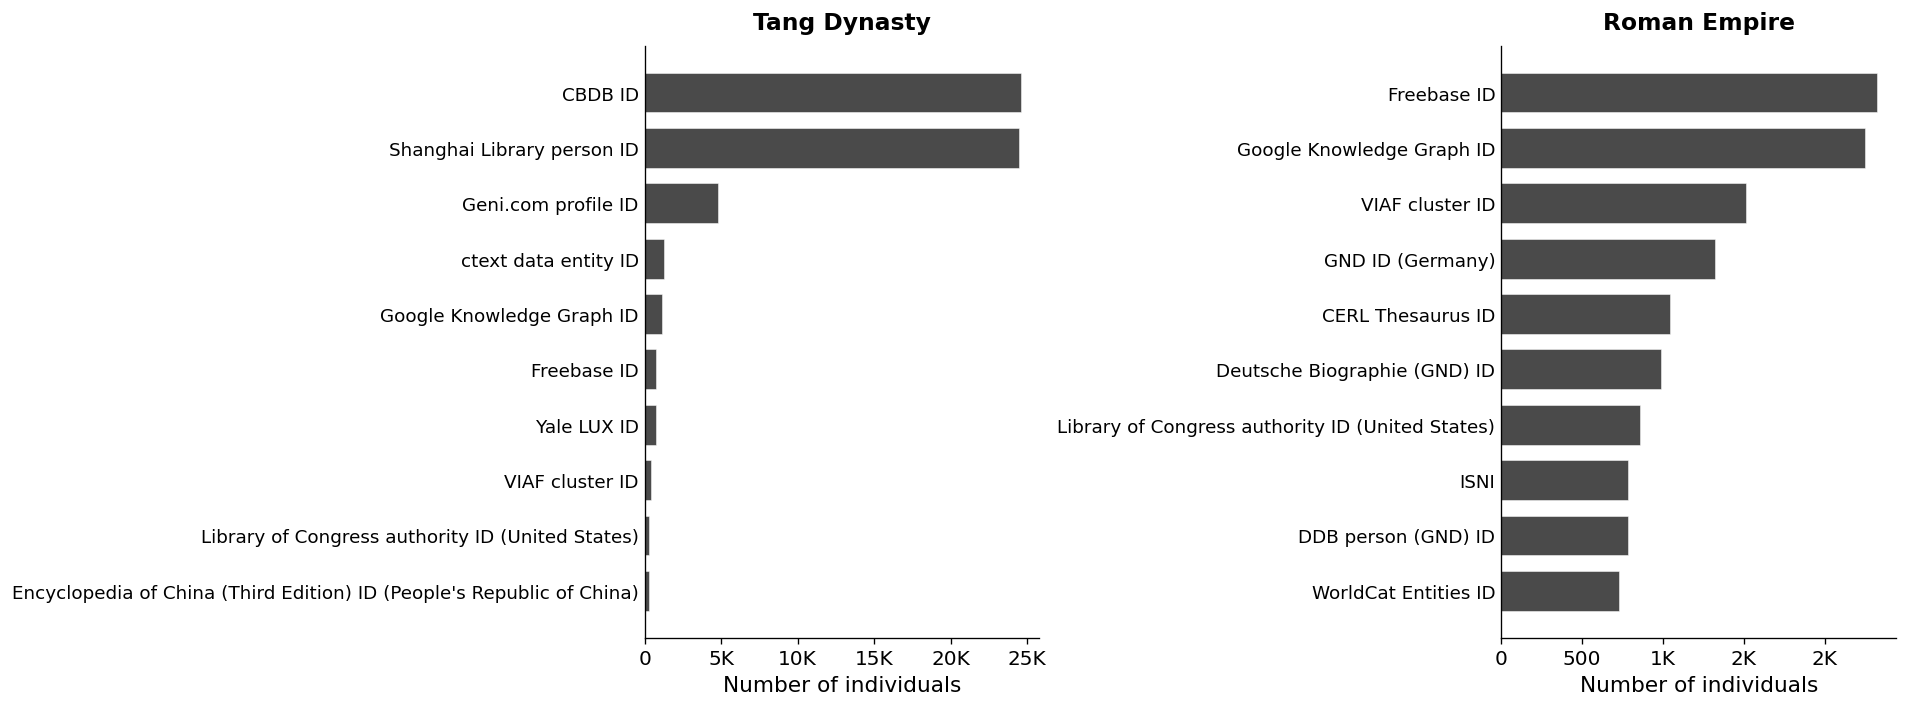

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, catalog_frame, title in [
    (axes[0], tang_top_catalogs,  'Tang Dynasty'),
    (axes[1], roman_top_catalogs, 'Roman Empire'),
]:
    rows = list(reversed(list(catalog_frame.iter_rows(named=True))))
    labels = [
        f"{row['identifier_name']} ({row['catalog_country']})" if row['catalog_country']
        else row['identifier_name']
        for row in rows
    ]
    counts = [row['individual_count'] for row in rows]
    y_positions = np.arange(len(rows))

    ax.barh(y_positions, counts, height=0.72, color=COLORS['neutral_bar'],
            edgecolor='white', linewidth=0.3)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Number of individuals')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'
    ))
    ax.tick_params(axis='y', length=0)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


## Fig 4 — Exclusive coverage by birth decade — four polities

In [23]:
PANEL_POLITIES = [
    'Japan',
    'Union of Soviet Socialist Republics',
    'Republic of Korea',
    'Republic of Turkey',
]
DECADE_BIN_SIZE = 10
BIRTH_YEAR_MIN  = 1700
BIRTH_YEAR_MAX  = 2025

four_polity_panel = (
    individual_coverage
    .filter(pl.col('polity_name').is_in(PANEL_POLITIES))
    .filter(pl.col('birth_year').is_not_null())
    .filter((pl.col('birth_year') > BIRTH_YEAR_MIN) & (pl.col('birth_year') <= BIRTH_YEAR_MAX))
    .with_columns(
        (pl.col('has_western_catalog')     | pl.col('has_western_wikipedia')).alias('any_western'),
        (pl.col('has_non_western_catalog') | pl.col('has_non_western_wikipedia')).alias('any_non_western'),
    )
    .with_columns(
        pl.when(pl.col('any_western')     & ~pl.col('any_non_western')).then(pl.lit('Western only'))
        .when(pl.col('any_non_western') & ~pl.col('any_western')).then(pl.lit('Non-Western only'))
        .otherwise(pl.lit('other'))
        .alias('exclusive_group'),
        ((pl.col('birth_year') // DECADE_BIN_SIZE) * DECADE_BIN_SIZE).alias('decade'),
    )
)

print('shape:', four_polity_panel.shape)
four_polity_panel.head()


shape: (463026, 14)


wikidata_id,polity_name,floruit_period_start,birth_year,has_western_catalog,has_non_western_catalog,has_international_catalog,has_western_wikipedia,has_non_western_wikipedia,coverage,any_western,any_non_western,exclusive_group,decade
str,str,i32,i64,bool,bool,bool,bool,bool,str,bool,bool,str,i64
"""Q107522041""","""Union of Soviet Socialist Repu…",1976,1946,false,true,false,false,true,"""non_western_catalog_only""",false,true,"""Non-Western only""",1940
"""Q107522124""","""Republic of Korea""",1999,1971,false,false,false,false,false,"""no_catalog_no_wikipedia""",false,false,"""other""",1970
"""Q107522156""","""Japan""",2003,1973,true,true,false,false,true,"""both_catalogs""",true,true,"""other""",1970
"""Q107522569""","""Japan""",1986,1956,false,true,false,false,true,"""non_western_catalog_only""",false,true,"""Non-Western only""",1950
"""Q107522664""","""Japan""",2012,1982,true,true,false,false,true,"""both_catalogs""",true,true,"""other""",1980


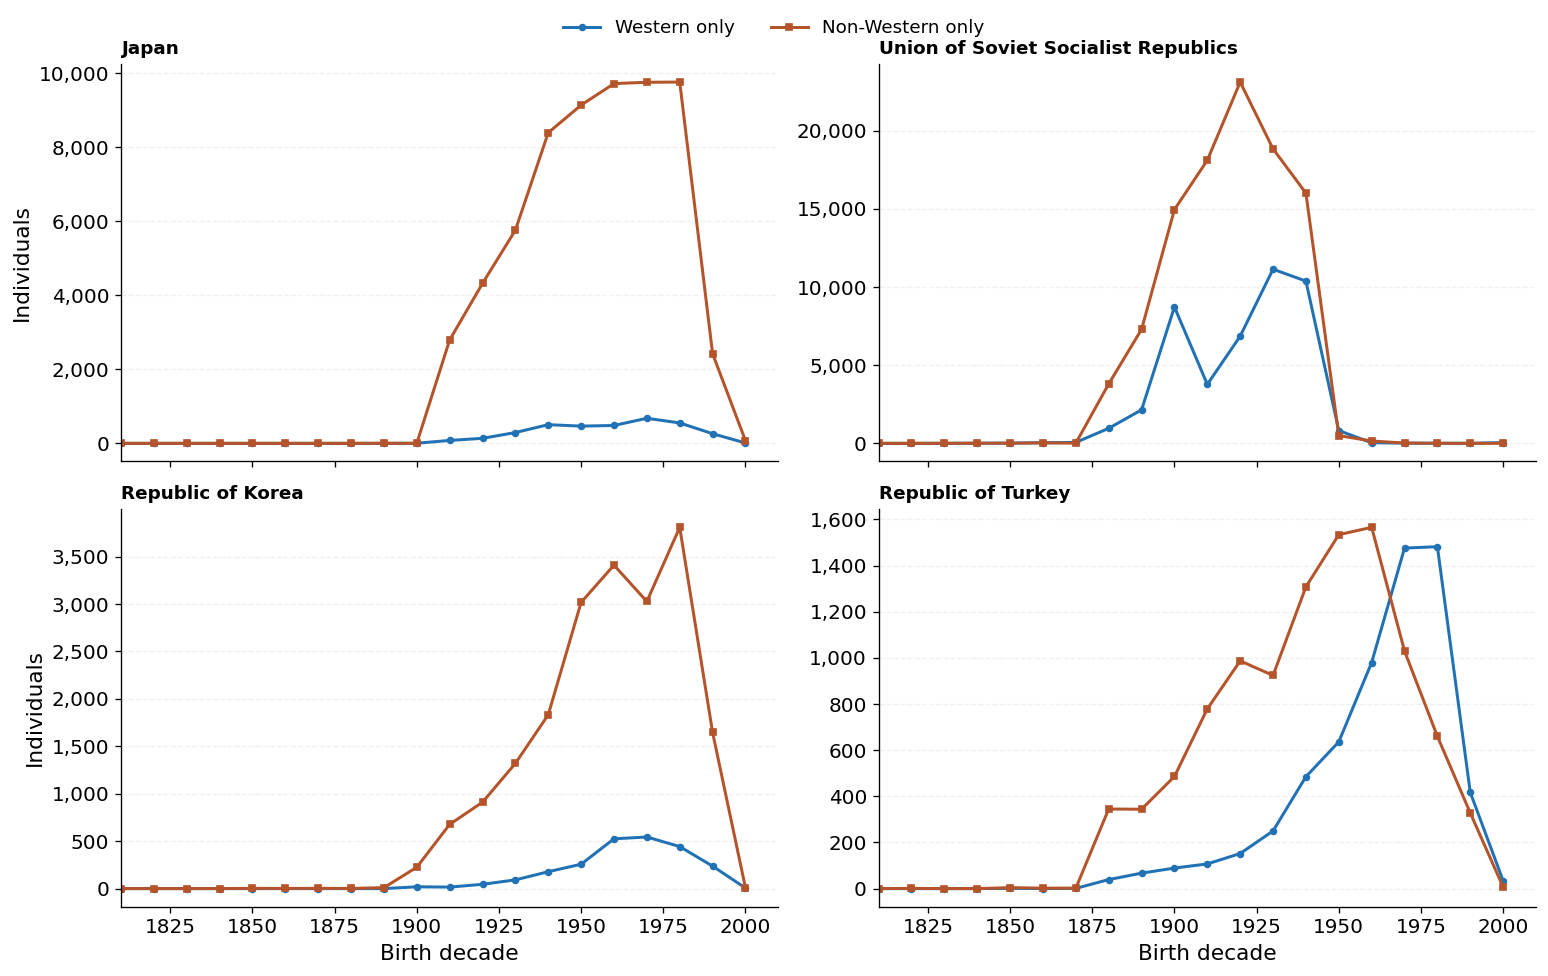

In [24]:
decade_min = int(four_polity_panel['decade'].min())
decade_max = int(four_polity_panel['decade'].max())
all_decades = np.arange(decade_min, decade_max + DECADE_BIN_SIZE, DECADE_BIN_SIZE)

def counts_per_decade(polity_subset, group_label):
    counts_by_decade = (
        polity_subset
        .filter(pl.col('exclusive_group') == group_label)
        .group_by('decade').len()
    )
    counts_lookup = dict(counts_by_decade.iter_rows())
    return np.array([counts_lookup.get(int(d), 0) for d in all_decades])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, polity in zip(axes.flat, PANEL_POLITIES):
    polity_rows = four_polity_panel.filter(pl.col('polity_name') == polity)
    western_counts     = counts_per_decade(polity_rows, 'Western only')
    non_western_counts = counts_per_decade(polity_rows, 'Non-Western only')

    ax.plot(all_decades, western_counts,
            color=COLORS['western_catalog'], lw=1.8, marker='o', ms=3.5, label='Western only')
    ax.plot(all_decades, non_western_counts,
            color=COLORS['non_western_catalog'], lw=1.8, marker='s', ms=3.5, label='Non-Western only')

    nonzero_idx = np.flatnonzero((western_counts + non_western_counts) > 0)
    if nonzero_idx.size:
        ax.set_xlim(all_decades[nonzero_idx[0]] - DECADE_BIN_SIZE,
                    all_decades[nonzero_idx[-1]] + DECADE_BIN_SIZE)

    ax.set_title(polity, fontsize=11, fontweight='bold', loc='left')
    ax.grid(axis='y', alpha=0.18, ls='--')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

for ax in axes[-1, :]:
    ax.set_xlabel('Birth decade')
for ax in axes[:, 0]:
    ax.set_ylabel('Individuals')

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=2,
           frameon=False, bbox_to_anchor=(0.5, 1.02), fontsize=11)
fig.tight_layout()
plt.show()


## Fig 5 — Sankey: catalogs → main Chinese polities

In [25]:
POLITY_TO_MAIN_CHINESE = {
    'Shang Dynasty':                   'Shang',
    'Zhou Dynasty':                    'Zhou',
    'Qin Dynasty':                     'Qin',
    'Han Dynasty':                     'Han',
    'Xin Dynasty':                     'Han',
    'Western Jin':                     'Six Dynasties',
    'Liu Song Dynasty':                'Six Dynasties',
    'Liang Dynasty':                   'Six Dynasties',
    'Chen Dynasty':                    'Six Dynasties',
    'Northern Wei':                    'Six Dynasties',
    'Eastern Wei':                     'Six Dynasties',
    'Western Wei':                     'Six Dynasties',
    'Northern Zhou':                   'Six Dynasties',
    'Northern Qi':                     'Six Dynasties',
    'Sui Dynasty':                     'Sui',
    'Tang Dynasty':                    'Tang',
    'Five Dynasties and Ten Kingdoms': 'Five Dynasties',
    'Liao Dynasty':                    'Five Dynasties',
    'Western Xia':                     'Five Dynasties',
    'Northern Song':                   'Song',
    'Southern Song':                   'Song',
    'Yuan Dynasty':                    'Yuan',
    'Ming Dynasty':                    'Ming',
    'Qing Dynasty':                    'Qing',
}
MAIN_CHINESE_ORDER = [
    'Shang', 'Zhou', 'Qin', 'Han', 'Six Dynasties', 'Sui',
    'Tang', 'Five Dynasties', 'Song', 'Yuan', 'Ming', 'Qing',
]
TOP_N_CATALOGS  = 12
MIN_RIBBON_SIZE = 5
WIKI_NAME_PATTERN = '(?i)wikipedia|wikidata|wikimedia|wikisource'

chinese_individual_catalog_polity = (
    catalog_names
    .filter(pl.col('polity_name').is_in(list(POLITY_TO_MAIN_CHINESE)))
    .filter(~pl.col('identifier_name').str.contains(WIKI_NAME_PATTERN))
    .with_columns(
        pl.col('polity_name').replace_strict(POLITY_TO_MAIN_CHINESE).alias('main_polity')
    )
    .select('wikidata_id', 'identifier_name', 'main_polity')
    .unique()
)

catalog_ranks = (
    chinese_individual_catalog_polity
    .group_by('identifier_name')
    .agg(pl.col('wikidata_id').n_unique().alias('individual_count'))
    .sort('individual_count', descending=True)
)
top_catalogs = catalog_ranks.head(TOP_N_CATALOGS)['identifier_name'].to_list()

chinese_individual_catalog_polity = chinese_individual_catalog_polity.with_columns(
    pl.when(pl.col('identifier_name').is_in(top_catalogs))
      .then(pl.col('identifier_name'))
      .otherwise(pl.lit('Other catalogs'))
      .alias('catalog_group')
)
CATALOG_ORDER = top_catalogs + ['Other catalogs']

sankey_flows = (
    chinese_individual_catalog_polity
    .select('wikidata_id', 'catalog_group', 'main_polity')
    .unique()
    .group_by('catalog_group', 'main_polity')
    .agg(pl.col('wikidata_id').n_unique().alias('individual_count'))
    .filter(pl.col('individual_count') >= MIN_RIBBON_SIZE)
    .sort('catalog_group', 'main_polity')
)

print('chinese_individual_catalog_polity shape:', chinese_individual_catalog_polity.shape)
print('sankey_flows shape:                     ', sankey_flows.shape)
sankey_flows.head()


chinese_individual_catalog_polity shape: (277549, 4)
sankey_flows shape:                      (124, 3)


catalog_group,main_polity,individual_count
str,str,u32
"""Academia Sinica authority ID""","""Han""",5
"""Academia Sinica authority ID""","""Ming""",3302
"""Academia Sinica authority ID""","""Qing""",8206
"""Academia Sinica authority ID""","""Song""",31
"""Academia Sinica authority ID""","""Tang""",11


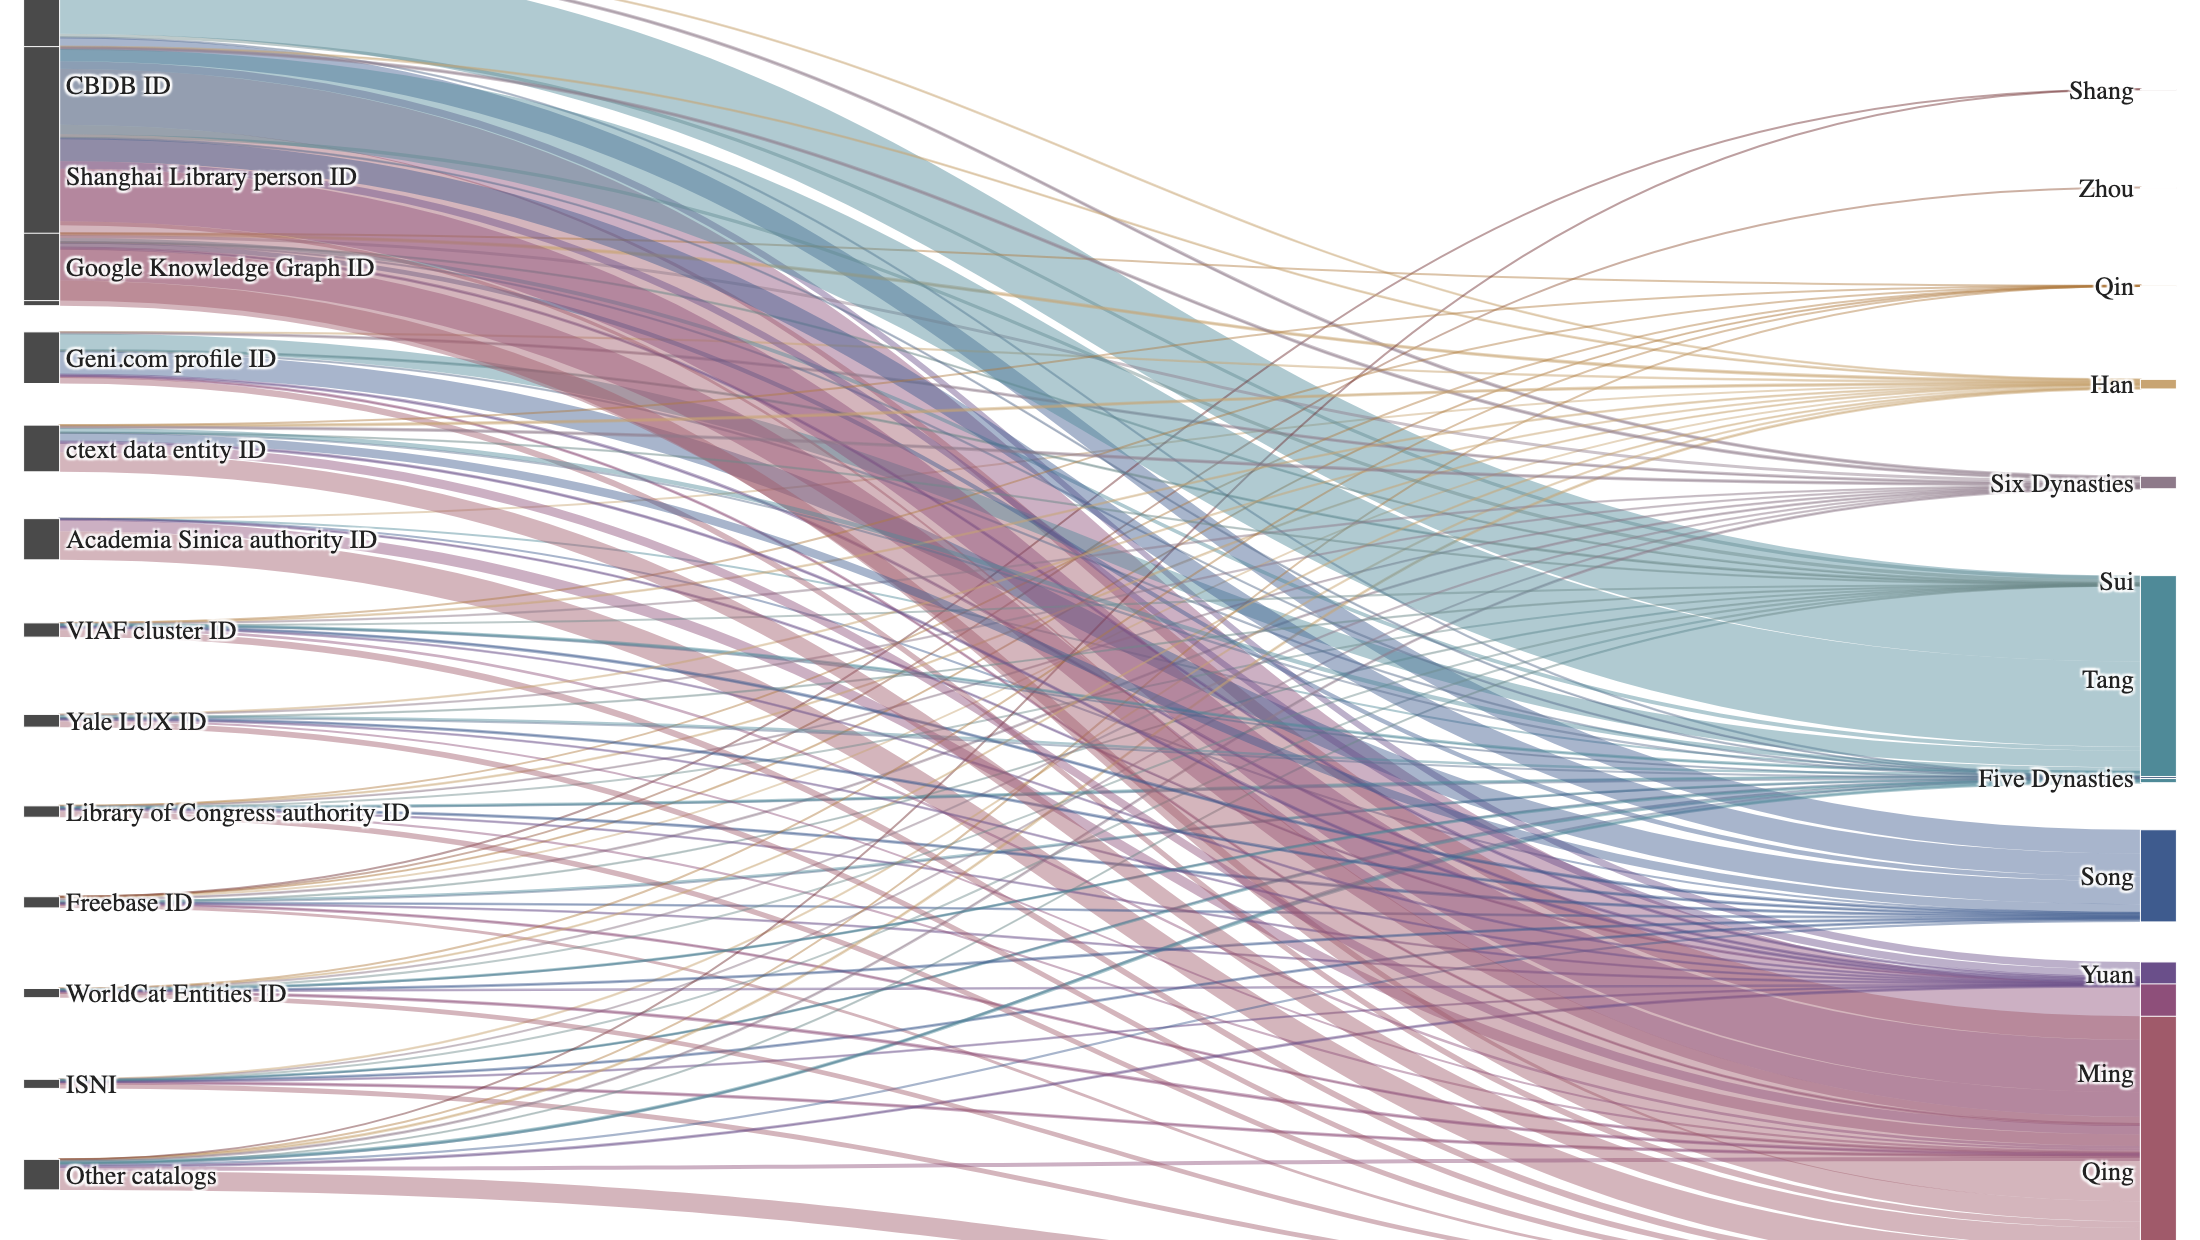

In [26]:
def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

node_labels = list(CATALOG_ORDER) + list(MAIN_CHINESE_ORDER)
node_colors = (
    [COLORS['neutral_bar']] * len(CATALOG_ORDER)
    + [CHINESE_POLITY_COLORS[m] for m in MAIN_CHINESE_ORDER]
)
catalog_index = {catalog: i for i, catalog in enumerate(CATALOG_ORDER)}
polity_index  = {polity:  len(CATALOG_ORDER) + i for i, polity in enumerate(MAIN_CHINESE_ORDER)}

source_indices = [catalog_index[c] for c in sankey_flows['catalog_group']]
target_indices = [polity_index[m]  for m in sankey_flows['main_polity']]
flow_values    = sankey_flows['individual_count'].to_list()
link_colors    = [hex_to_rgba(CHINESE_POLITY_COLORS[m], 0.45) for m in sankey_flows['main_polity']]

n_catalogs = len(CATALOG_ORDER)
n_polities = len(MAIN_CHINESE_ORDER)
catalog_x  = [0.01] * n_catalogs
catalog_y  = [(i + 0.5) / n_catalogs for i in range(n_catalogs)]
polity_x   = [0.99] * n_polities
polity_y   = [(i + 0.5) / n_polities for i in range(n_polities)]

fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(
        pad=14, thickness=18,
        line=dict(color='white', width=0.5),
        label=node_labels, color=node_colors,
        x=catalog_x + polity_x, y=catalog_y + polity_y,
        hovertemplate='%{label}<br>%{value:,} individuals<extra></extra>',
    ),
    link=dict(
        source=source_indices, target=target_indices, value=flow_values, color=link_colors,
        hovertemplate=(
            '%{source.label} → %{target.label}'
            '<br>%{value:,} individuals<extra></extra>'
        ),
    ),
)])
fig.update_layout(
    font=dict(family='DejaVu Sans', size=13, color='#222'),
    paper_bgcolor='white', plot_bgcolor='white',
    margin=dict(l=10, r=10, t=20, b=10),
    width=1100, height=620,
)
Image(fig.to_image(format='png', width=1100, height=620, scale=2))
